In [102]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import boxcox

#### Full model summary

In [103]:
#Load model-ready data
df = pd.read_csv("kidney_disease_model_ready.csv")

# Define response variable
y = df["sc"]  # serum creatinine

#Build full predictor matrix drop response
X_full = df.drop(columns=["sc"])

#Add intercept and fit FULL model
X_full_const = sm.add_constant(X_full)
full_model = sm.OLS(y, X_full_const).fit()

print(full_model.summary())
params = full_model.params  
equation = "sc_hat = "




                            OLS Regression Results                            
Dep. Variable:                     sc   R-squared:                       0.876
Model:                            OLS   Adj. R-squared:                  0.855
Method:                 Least Squares   F-statistic:                     41.11
Date:                Tue, 25 Nov 2025   Prob (F-statistic):           1.46e-49
Time:                        22:27:37   Log-Likelihood:                -236.48
No. Observations:                 158   AIC:                             521.0
Df Residuals:                     134   BIC:                             594.5
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         -10.8754     30.675     -0.355      

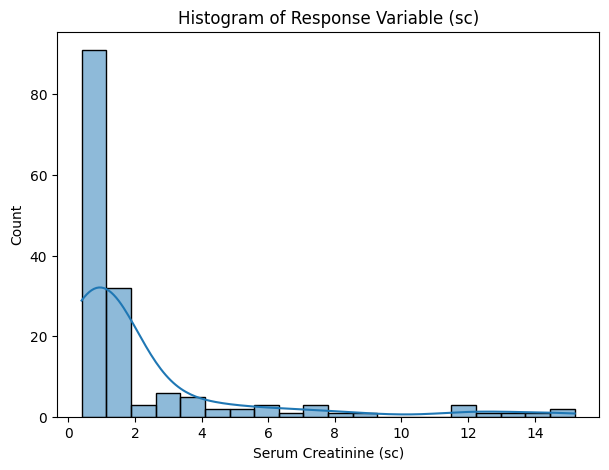

In [104]:
# Histogram of serum creatinine (sc)
plt.figure(figsize=(7,5))
sns.histplot(df["sc"], kde=True, bins=20)
plt.xlabel("Serum Creatinine (sc)")
plt.title("Histogram of Response Variable (sc)")
plt.show()

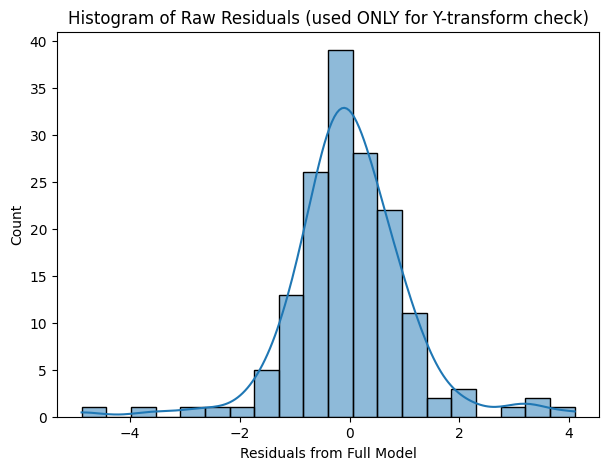

In [105]:
# Raw residuals of full model
resid_full = full_model.resid

plt.figure(figsize=(7,5))
sns.histplot(resid_full, kde=True, bins=20)
plt.xlabel("Residuals from Full Model")
plt.title("Histogram of Raw Residuals (used ONLY for Y-transform check)")
plt.show()

In [114]:

y_bc, lambda_opt = boxcox(df["sc"])
print("Optimal Box-Cox lambda:", lambda_opt)

Optimal Box-Cox lambda: -0.7108624125483377


#### VIF Table

In [115]:
#Compute VIF for each predictor (using X_full, no intercept)
X_vif = X_full.copy()

vif_data = []
for i in range(X_vif.shape[1]):
    vif = variance_inflation_factor(X_vif.values, i)
    vif_data.append({"feature": X_vif.columns[i], "VIF": vif})

vif_df = pd.DataFrame(vif_data)
vif_df = vif_df.sort_values("VIF", ascending=False).reset_index(drop=True)

print(vif_df)

        feature         VIF
0            sg 1063.873582
1           sod  734.957014
2          hemo  127.639386
3           pcv  122.161878
4            rc   69.607997
5            bp   65.841442
6     pc_normal   22.772534
7    rbc_normal   20.477171
8           bgr   17.552844
9           age   14.249877
10           wc   12.453238
11           al    7.516191
12      htn_yes    7.260139
13           bu    7.103155
14       dm_yes    6.212236
15          pot    4.520094
16       pe_yes    4.036256
17           su    3.767828
18      ane_yes    3.727296
19   appet_poor    3.120850
20  pcc_present    2.575665
21   ba_present    2.234367
22      cad_yes    2.070195


#### Full model predictors and pvalues

In [116]:
# 8. Get all p-values from the full model, printed without scientific notation
pd.set_option('display.float_format', lambda x: f'{x:.6f}')

print("\n===== P-VALUES (sorted, non-scientific) =====")
pvals_all_sorted = full_model.pvalues.sort_values()
print(pvals_all_sorted.to_string(float_format=lambda x: f'{x:.6f}'))



===== P-VALUES (sorted, non-scientific) =====
bu            0.000000
pot           0.000673
al            0.004637
pe_yes        0.006225
wc            0.007801
ane_yes       0.035166
pc_normal     0.040628
appet_poor    0.061572
bp            0.065111
ba_present    0.083435
rc            0.131206
pcv           0.171352
rbc_normal    0.224490
su            0.252530
hemo          0.263943
pcc_present   0.341343
bgr           0.439172
htn_yes       0.634915
sg            0.648456
age           0.662654
const         0.723495
cad_yes       0.778708
sod           0.977711
dm_yes        0.992364


#### Reduced Model Predictors

In [117]:
# 1. Get all p-values from full model (excluding intercept)
pvals = full_model.pvalues.drop("const")

# 2. Select predictors with p < 0.05
reduced_predictors = pvals[pvals < 0.05].index.tolist()

print(reduced_predictors)


['al', 'bu', 'pot', 'wc', 'pc_normal', 'pe_yes', 'ane_yes']


#### Reduced Model Summary using Backward Elmination

In [124]:
alpha = 0.10
X_current = X_full.copy()
removed_vars_raw = []
step = 0
while True:
    X_const = sm.add_constant(X_current)
    model_raw = sm.OLS(y, X_const).fit()
    
    # p-values for predictors (excluding intercept)
    pvals = model_raw.pvalues.drop("const")
    worst_p = pvals.max()
    worst_var = pvals.idxmax()
    
    print(f"Step {step}: max p-value = {worst_p:.4f} for variable '{worst_var}'")
    
    # stop when all remaining predictors have p < alpha
    if worst_p < alpha:
        print("\nAll remaining variables have p-values < alpha (raw Y).")
        break
    
    removed_vars_raw.append((worst_var, worst_p))
    X_current = X_current.drop(columns=[worst_var])
    step += 1

print("\nVariables removed in backward elimination (RAW Y, full start):")
for var, p in removed_vars_raw:
    print(f"  {var}: p = {p:.4f}")

print("\nFinal predictor set for RAW Y after BE:")
print(list(X_current.columns))


Step 0: max p-value = 0.9924 for variable 'dm_yes'
Step 1: max p-value = 0.9787 for variable 'sod'
Step 2: max p-value = 0.7767 for variable 'cad_yes'
Step 3: max p-value = 0.6349 for variable 'age'
Step 4: max p-value = 0.6040 for variable 'sg'
Step 5: max p-value = 0.4424 for variable 'htn_yes'
Step 6: max p-value = 0.3161 for variable 'hemo'
Step 7: max p-value = 0.2977 for variable 'pcc_present'
Step 8: max p-value = 0.2454 for variable 'su'
Step 9: max p-value = 0.5402 for variable 'bgr'
Step 10: max p-value = 0.1432 for variable 'rbc_normal'
Step 11: max p-value = 0.1175 for variable 'rc'
Step 12: max p-value = 0.0763 for variable 'appet_poor'

All remaining variables have p-values < alpha (raw Y).

Variables removed in backward elimination (RAW Y, full start):
  dm_yes: p = 0.9924
  sod: p = 0.9787
  cad_yes: p = 0.7767
  age: p = 0.6349
  sg: p = 0.6040
  htn_yes: p = 0.4424
  hemo: p = 0.3161
  pcc_present: p = 0.2977
  su: p = 0.2454
  bgr: p = 0.5402
  rbc_normal: p = 0.1432

In [125]:
X_reduced_raw_const = sm.add_constant(X_current)
reduced_model_raw = sm.OLS(y, X_reduced_raw_const).fit()

print("\n===== REDUCED MODEL SUMMARY (RAW Y = sc, after BE) =====")
print(reduced_model_raw.summary())


===== REDUCED MODEL SUMMARY (RAW Y = sc, after BE) =====
                            OLS Regression Results                            
Dep. Variable:                     sc   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.857
Method:                 Least Squares   F-statistic:                     86.68
Date:                Tue, 25 Nov 2025   Prob (F-statistic):           2.84e-58
Time:                        23:38:45   Log-Likelihood:                -241.80
No. Observations:                 158   AIC:                             507.6
Df Residuals:                     146   BIC:                             544.4
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

#### ANOVA Test Comparing Both Models

In [128]:
from statsmodels.stats.anova import anova_lm
#hypothesis test
print("\n=== Hypothesis Test for Model Reduction ===")
print("H0: The reduced model is adequate; the removed predictors do NOT improve model fit.")
print("H1: The full model fits significantly better than the reduced model.")

anova_results = anova_lm(reduced_model_raw, full_model)

#ANOVA results
print(anova_results)

# Extract p-value for the F-test comparing reduced vs full
# Row 0 = reduced model, Row 1 = full model
pval = anova_results["Pr(>F)"].iloc[1]
alpha = 0.05

print(f"\nANOVA p-value: {pval:.4f}")

if pval > alpha:
    print(f"Since p-value = {pval:.4f} > {alpha}, we FAIL to reject H0.")
    print("→ Conclusion: The reduced model is sufficient; we can keep the simpler model.")
else:
    print(f"Since p-value = {pval:.4f} ≤ {alpha}, we REJECT H0.")
    print("→ Conclusion: The full model is significantly better; we should use the full model.")



=== Hypothesis Test for Model Reduction ===
H0: The reduced model is adequate; the removed predictors do NOT improve model fit.
H1: The full model fits significantly better than the reduced model.
    df_resid        ssr   df_diff   ss_diff        F   Pr(>F)
0 146.000000 197.459493  0.000000       NaN      NaN      NaN
1 134.000000 184.579206 12.000000 12.880287 0.779231 0.670915

ANOVA p-value: 0.6709
Since p-value = 0.6709 > 0.05, we FAIL to reject H0.
→ Conclusion: The reduced model is sufficient; we can keep the simpler model.


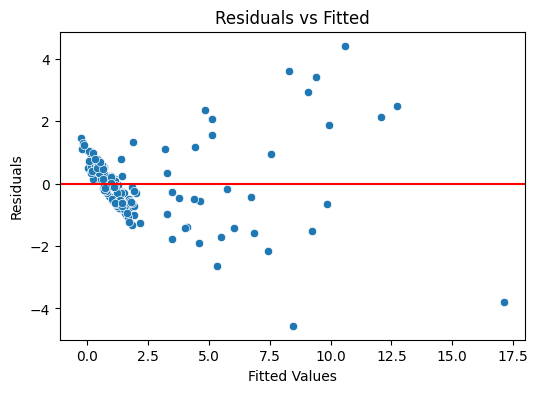

In [129]:
import matplotlib.pyplot as plt
import seaborn as sns

resid = reduced_model_raw.resid
fitted = reduced_model_raw.fittedvalues

plt.figure(figsize=(6,4))
sns.scatterplot(x=fitted, y=resid)
plt.axhline(0, color='red')
plt.title("Residuals vs Fitted")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()


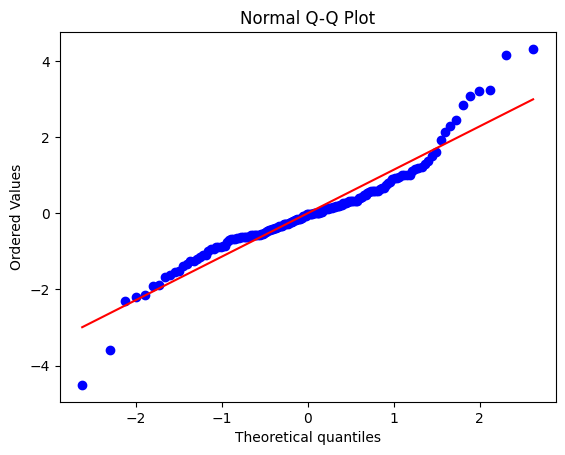

In [121]:
import scipy.stats as stats

stats.probplot(resid, dist="norm", plot=plt)
plt.title("Normal Q-Q Plot")
plt.show()


In [122]:
import numpy as np

rmse = np.sqrt(np.mean(resid**2))
print("RMSE:", rmse)


RMSE: 1.1736201275557634
